[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
[![Open On GitHub](https://img.shields.io/badge/Open-on%20GitHub-blue?logo=GitHub)](https://github.com/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)

# MNIST tutorial

Welcome to Flax NNX! In this tutorial you will learn how to build and train a simple convolutional neural network (CNN) to classify handwritten digits on the MNIST dataset using the Flax NNX API.

Flax NNX is a Python neural network library built upon [JAX](https://github.com/jax-ml/jax). If you have used the Flax Linen API before, check out [Why Flax NNX](https://flax.readthedocs.io/en/latest/why.html). You should have some knowledge of the main concepts of deep learning.

Let’s get started!

## 1. Install Flax

If `flax` is not installed in your Python environment, use `pip` to install the package from PyPI (below, just uncomment the code in the cell if you are working from Google Colab/Jupyter Notebook):

In [1]:
# !pip install -U "jax[cuda12]"
# !pip install -U flax
!pip install tensorflow_datasets
!pip install importlib_resources
!pip install jax
!pip install flax

## 2. Load the MNIST dataset

First, you need to load the MNIST dataset and then prepare the training and testing sets via Tensorflow Datasets (TFDS). You normalize image values, shuffle the data and divide it into batches, and prefetch samples to enhance performance.

In [2]:
import tensorflow_datasets as tfds  # TFDS to download MNIST.
import tensorflow as tf  # TensorFlow / `tf.data` operations.

tf.random.set_seed(0)  # Set the random seed for reproducibility.

train_steps = 5000
eval_every = 50
batch_size = 64

train_ds: tf.data.Dataset = tfds.load('mnist', split='train')
test_ds: tf.data.Dataset = tfds.load('mnist', split='test')

train_ds = train_ds.map(
  lambda sample: {
    'image': tf.cast(sample['image'], tf.float32) / 255,
    'label': sample['label'],
  }
)  # normalize train set
test_ds = test_ds.map(
  lambda sample: {
    'image': tf.cast(sample['image'], tf.float32) / 255,
    'label': sample['label'],
  }
)  # Normalize the test set.

# Create a shuffled dataset by allocating a buffer size of 1024 to randomly draw elements from.
train_ds = train_ds.repeat().shuffle(1024)
# Group into batches of `batch_size` and skip incomplete batches, prefetch the next sample to improve latency.
train_ds = train_ds.batch(batch_size, drop_remainder=True).take(train_steps).prefetch(1)
# Group into batches of `batch_size` and skip incomplete batches, prefetch the next sample to improve latency.
test_ds = test_ds.batch(batch_size, drop_remainder=True).prefetch(1)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/compphys/tensorflow_datasets/mnist/incomplete.NXRHRG_3.0.1/mnist-train.tfrecord*...:   0%|    …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/compphys/tensorflow_datasets/mnist/incomplete.NXRHRG_3.0.1/mnist-test.tfrecord*...:   0%|     …

Dataset mnist downloaded and prepared to /home/compphys/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


## 3. Define the model with Flax NNX

Create a CNN for classification with Flax NNX by subclassing `nnx.Module`:

In [3]:
from flax import nnx  # The Flax NNX API.
from functools import partial
from typing import Optional
import numpy as np
import jax.numpy as jnp
import seaborn as sns
import hist

In [7]:
class CNN(nnx.Module):
  """A simple CNN model."""

  def __init__(self, *, rngs: nnx.Rngs):
    self.conv1 = nnx.Conv(1, 32, kernel_size=(5, 5), rngs=rngs)
    self.dropout1 = nnx.Dropout(rate=0.1)
    self.batch_norm1 = nnx.BatchNorm(32, rngs=rngs)
    self.avg_pool1 = partial(nnx.avg_pool, window_shape=(2, 2), strides=(2, 2))
      
    self.conv2 = nnx.Conv(32, 64, kernel_size=(5, 5), rngs=rngs)
    self.dropout2 = nnx.Dropout(rate=0.1)
    self.batch_norm2 = nnx.BatchNorm(64, rngs=rngs)
    self.avg_pool2 = partial(nnx.avg_pool, window_shape=(2, 2), strides=(2, 2))

    self.linear1 = nnx.Linear(3136, 128, rngs=rngs)
    self.dropoutN = nnx.Dropout(rate=0.1)
    self.linear2 = nnx.Linear(128, 10, rngs=rngs)

  def __call__(self, x, rngs: nnx.Rngs | None = None):
    x = self.avg_pool1(nnx.relu(self.batch_norm1(self.dropout1(self.conv1(x), rngs=rngs))))
    x = self.avg_pool2(nnx.relu(self.batch_norm2(self.dropout2(self.conv2(x), rngs=rngs))))
    x = x.reshape(x.shape[0], -1)  # flatten
    x = nnx.relu(self.dropoutN(self.linear1(x), rngs=rngs))
    x = self.linear2(x)
    return x

# Instantiate the model.
cnn_model = CNN(rngs=nnx.Rngs(0))
# Visualize it.
nnx.display(cnn_model)

In [8]:
# Access the kernel variable's shape
kernel_shape = cnn_model.conv1.kernel.get_value().shape
print(f"Kernel shape: {kernel_shape}")

# Calculate the total number of weights
# The number of weights is (kernel_height * kernel_width * input_channels * output_channels)
number_of_weights = jnp.size(cnn_model.conv1.kernel.value)
print(f"Total number of weights in layer conv1: {number_of_weights}")


Kernel shape: (5, 5, 1, 32)
Total number of weights in layer conv1: 800


/tmp/ipykernel_1898/1609233931.py:7: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  number_of_weights = jnp.size(cnn_model.conv1.kernel.value)


### Run the model

Let's put the CNN model to the test!  Here, you’ll perform a forward pass with arbitrary data and print the results.

In [9]:
import jax.numpy as jnp  # JAX NumPy

y = cnn_model(jnp.ones((1, 28, 28, 1)), nnx.Rngs(0))
y

Array([[ 0.36886114,  0.08035579, -0.6725075 , -0.44564644, -0.23996967,
         0.10011809,  0.83743596,  0.13590136, -0.17537045, -0.11727232]],      dtype=float32)

## 4. Create the optimizer and define some metrics

In Flax NNX, you need to create an `nnx.Optimizer` object to manage the model's parameters and apply gradients during training. `nnx.Optimizer` receives the model's reference, so that it can update its parameters, and an [Optax](https://optax.readthedocs.io/) optimizer to define the update rules. Additionally, you will define an `nnx.MultiMetric` object to keep track of the `Accuracy` and the `Average` loss.

In [10]:
import optax

learning_rate = 0.005
momentum = 0.9

optimizer = nnx.Optimizer(
  cnn_model, optax.adamw(learning_rate, momentum), wrt=nnx.Param
)
metrics = nnx.MultiMetric(
  accuracy=nnx.metrics.Accuracy(),
  loss=nnx.metrics.Average('loss'),
)

nnx.display(optimizer)

## 5. Define training step functions

In this section, you will define a loss function using the cross entropy loss ([`optax.softmax_cross_entropy_with_integer_labels()`](https://optax.readthedocs.io/en/latest/api/losses.html#optax.softmax_cross_entropy_with_integer_labels)) that the CNN model will optimize over.

In addition to the `loss`, during training and testing you will also get the `logits`, which will be used to calculate the accuracy metric.

During training — the `train_step` — you will use `nnx.value_and_grad` to compute the gradients and update the model's parameters using the `optimizer` you have already defined. The `train_step` also receives an `nnx.Rngs` object to provide randomness for dropout. The `eval_step` omits `rngs` because the eval view already has `deterministic=True`, so dropout is disabled and no random key is needed. During both steps, the `loss` and `logits` are used to update the metrics.

In [11]:
def loss_fn(model: CNN, batch, rngs: nnx.Rngs | None = None):
  logits = model(batch['image'], rngs)
  loss = optax.softmax_cross_entropy_with_integer_labels(
    logits=logits, labels=batch['label']
  ).mean()
  return loss, logits

@nnx.jit
def train_step(model: CNN, optimizer: nnx.Optimizer, metrics: nnx.MultiMetric, rngs: nnx.Rngs, batch):
  """Train for a single step."""
  grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
  (loss, logits), grads = grad_fn(model, batch, rngs)
  metrics.update(loss=loss, logits=logits, labels=batch['label'])  # In-place updates.
  optimizer.update(model, grads)  # In-place updates.

@nnx.jit
def eval_step(model: CNN, metrics: nnx.MultiMetric, batch):
  loss, logits = loss_fn(model, batch)
  metrics.update(loss=loss, logits=logits, labels=batch['label'])  # In-place updates.

In the code above, the [`nnx.jit`](https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/transforms.html#flax.nnx.jit) transformation decorator traces the `train_step` function for just-in-time compilation with [XLA](https://www.tensorflow.org/xla), optimizing performance on hardware accelerators, such as Google TPUs and GPUs. `nnx.jit` is a stateful version of the `jax.jit` transform that allows its function input and outputs to be Flax NNX objects. Similarly, `nnx.value_and_grad` is a stateful version of `jax.value_and_grad`. Check out [the transforms guide](https://flax.readthedocs.io/en/latest/guides/transforms.html) to learn more.

> **Note:** The code shows how to perform several in-place updates to the model, the optimizer, the RNG streams, and the metrics, but _state updates_ were not explicitly returned. This is because Flax NNX transformations respect _reference semantics_ for Flax NNX objects, and will propagate the state updates of the objects passed as input arguments. This is a key feature of Flax NNX that allows for a more concise and readable code. You can learn more in [Why Flax NNX](https://flax.readthedocs.io/en/latest/why.html).


## 6. Train and evaluate the model

Now, you can train the CNN model. Before the training loop, we use [`nnx.view`](https://flax.readthedocs.io/en/latest/guides/view.html) to create a `train_model` (with dropout enabled and batch norm in training mode) and an `eval_model` (with dropout disabled and batch norm using running statistics). These views share the same underlying weights, so updates during training are automatically reflected during evaluation.

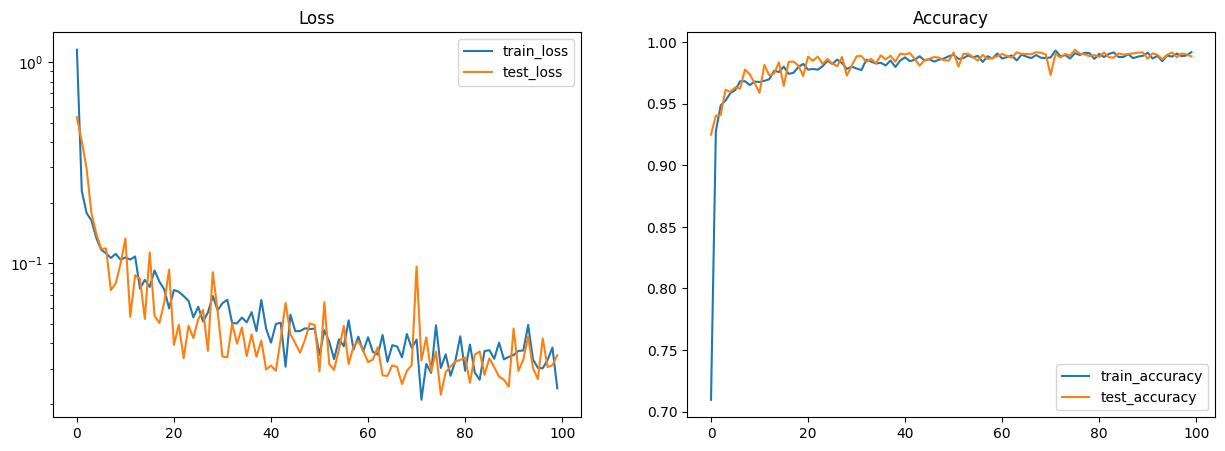

In [12]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

metrics_history = {
  'train_loss': [],
  'train_accuracy': [],
  'test_loss': [],
  'test_accuracy': [],
}

rngs = nnx.Rngs(0)
train_model = nnx.view(cnn_model, deterministic=False, use_running_average=False)
eval_model = nnx.view(cnn_model, deterministic=True, use_running_average=True)

for step, batch in enumerate(train_ds.as_numpy_iterator()):
  # Run the optimization for one step and make a stateful update to the following:
  # - The train state's model parameters
  # - The optimizer state
  # - The training loss and accuracy batch metrics
  train_step(train_model, optimizer, metrics, rngs, batch)

  if step > 0 and (step % eval_every == 0 or step == train_steps - 1):  # One training epoch has passed.
    # Log the training metrics.
    for metric, value in metrics.compute().items():  # Compute the metrics.
      metrics_history[f'train_{metric}'].append(value)  # Record the metrics.
    metrics.reset()  # Reset the metrics for the test set.

    # Compute the metrics on the test set after each training epoch.
    for test_batch in test_ds.as_numpy_iterator():
      eval_step(eval_model, metrics, test_batch)

    # Log the test metrics.
    for metric, value in metrics.compute().items():
      metrics_history[f'test_{metric}'].append(value)
    metrics.reset()  # Reset the metrics for the next training epoch.

    clear_output(wait=True)
    # Plot loss and accuracy in subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.set_title('Loss')
    ax2.set_title('Accuracy')
    for dataset in ('train', 'test'):
      ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss')
      ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy')
    ax1.legend()
    ax1.set_yscale("log")
    ax2.legend()
    plt.show()

## 7. Perform inference on the test set

Create a `jit`-compiled model inference function (with `nnx.jit`) - `pred_step` - to generate predictions on the test set using the learned model parameters. Since we already have `eval_model` (an `nnx.view` with `deterministic=True` and `use_running_average=True`), we can use it directly for inference. This will enable you to visualize test images alongside their predicted labels for a qualitative assessment of model performance.

In [13]:
@nnx.jit
def pred_step(model: CNN, batch):
  logits = model(batch['image'], None)
  return logits.argmax(axis=1)

We reuse the `eval_model` view created earlier so that `Dropout` is disabled and `BatchNorm` uses stored running stats during inference.

2026-03-31 21:02:50.464228: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25690112 exceeds 10% of free system memory.
2026-03-31 21:02:50.599615: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25690112 exceeds 10% of free system memory.
2026-03-31 21:02:50.600056: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


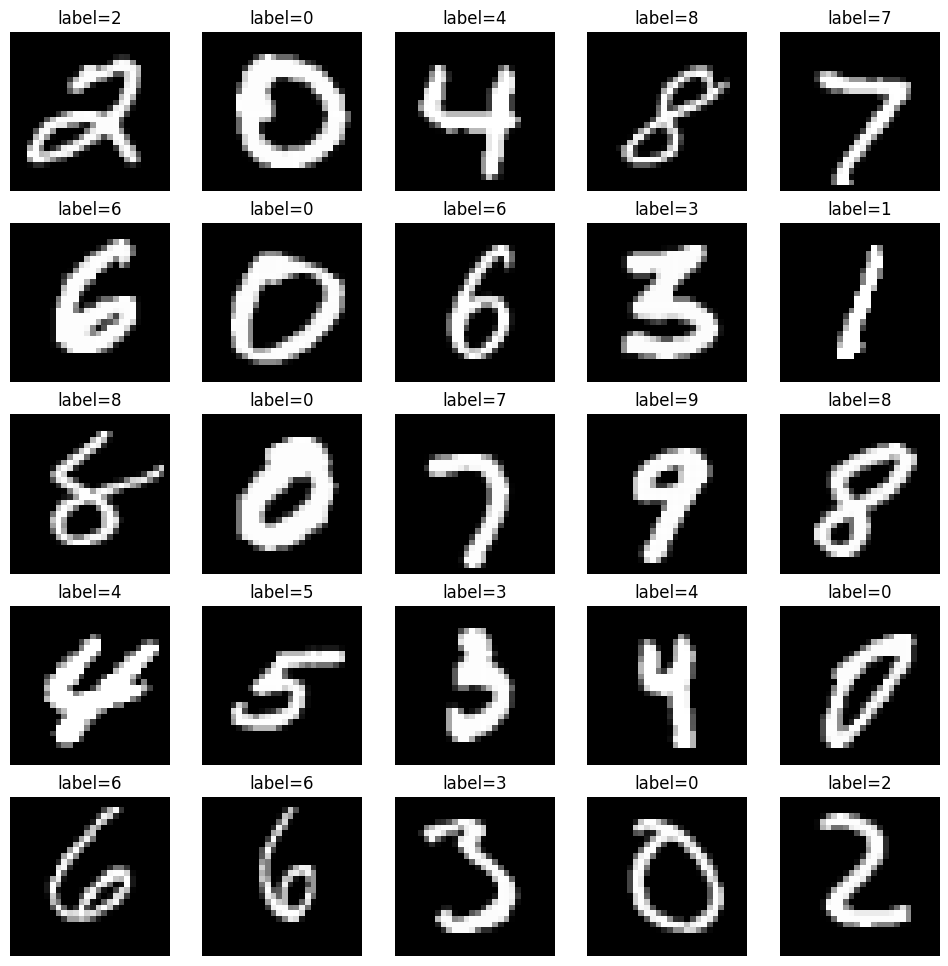

In [14]:
test_ds2: tf.data.Dataset = tfds.load('mnist', split='test')
test_ds2 = test_ds2.map(
  lambda sample: {
    'image': tf.cast(sample['image'], tf.float32) / 255,
    'label': sample['label'],
  }
)
test_ds2 = test_ds2.batch(8192, drop_remainder=True).prefetch(1)

test_batch = test_ds2.as_numpy_iterator().next()
pred = pred_step(eval_model, test_batch)

fig, axs = plt.subplots(5, 5, figsize=(12, 12))
for i, ax in enumerate(axs.flatten()):
  ax.imshow(test_batch['image'][i, ..., 0], cmap='gray')
  ax.set_title(f'label={pred[i]}')
  ax.axis('off')

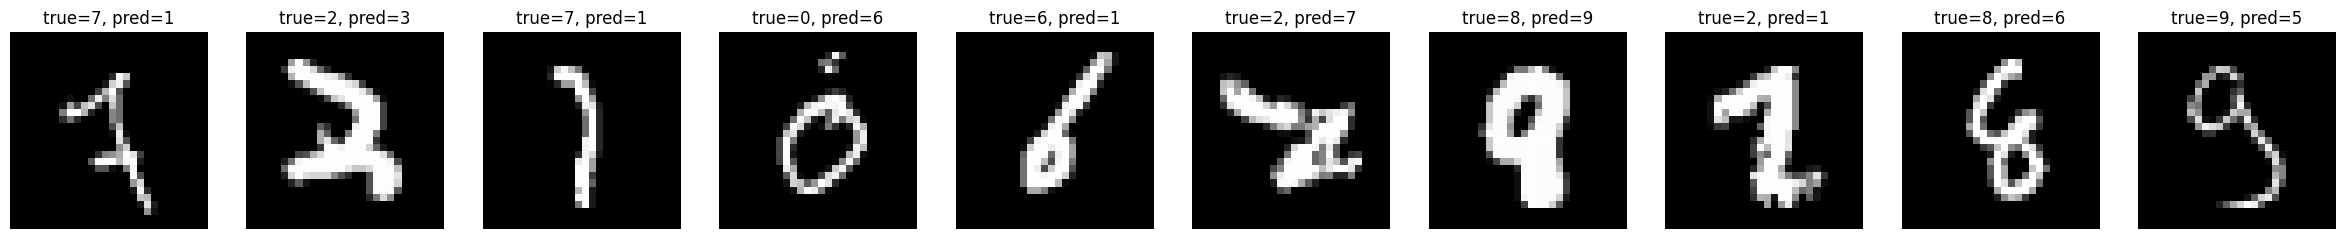

In [15]:
# Plot mistakes
bad_images = test_batch["image"][pred != test_batch["label"]]
bad_labels = test_batch["label"][pred != test_batch["label"]]
bad_preds = pred[pred != test_batch["label"]]
#print(bad_labels)

n = min(bad_labels.size, 10)
fig, axs = plt.subplots(1, n, figsize=(3*n, 6))
if n == 0:
    print("No bad predictions")
elif n == 1:
    #print(bad_images)
    axs.imshow(bad_images[0], cmap="gray")
    axs.set_title(f"true={bad_labels[0]}, pred={bad_preds[0]}")
    axs.axis("off")
else:    
    for i, ax in enumerate(axs):
        ax.imshow(bad_images[i], cmap="gray")
        ax.set_title(f"true={bad_labels[i]}, pred={bad_preds[i]}")
        ax.axis("off")


In [16]:
# Compute accuracy
print(pred)
print(test_batch["label"])
acc = np.sum(pred == test_batch["label"]) / test_batch["label"].size
print(f"Accuracy = {acc}")

[2 0 4 ... 8 6 2]
[2 0 4 ... 8 6 2]
Accuracy = 0.98876953125


In [17]:
# Make a ROC curve
@nnx.jit
def prob_step(model: CNN, batch):
  logits = model(batch['image'], None)
  prob = (jnp.exp(logits).T / jnp.sum(jnp.exp(logits), axis=1)).T
  return prob
    
prob = prob_step(eval_model, test_batch)
#print(prob.shape)
#print(prob[:10, :])

@nnx.jit
def binary_classify(model: CNN, batch, label: int, thresholds: np.typing.ArrayLike):  
    ''' 
    Return results of binary classification for class=label
    Shape: (batch_size, threshold_vals)
    '''
    logits = model(batch['image'], None)
    probs = prob_step(model, batch)[:, label]
    results = probs > thresholds[:, np.newaxis]
    return results

probs = {}
binary_results = {}
# Thresholds: logarithmic-ish near 1
thresholds = 1. - 10**np.linspace(-6, 0., 300)
#thresholds = np.linspace(0., 1., 100)
for cat in range(10):
    probs[cat] = prob_step(eval_model, test_batch)[:, cat]
    binary_results[cat] = binary_classify(eval_model, test_batch, cat, thresholds)

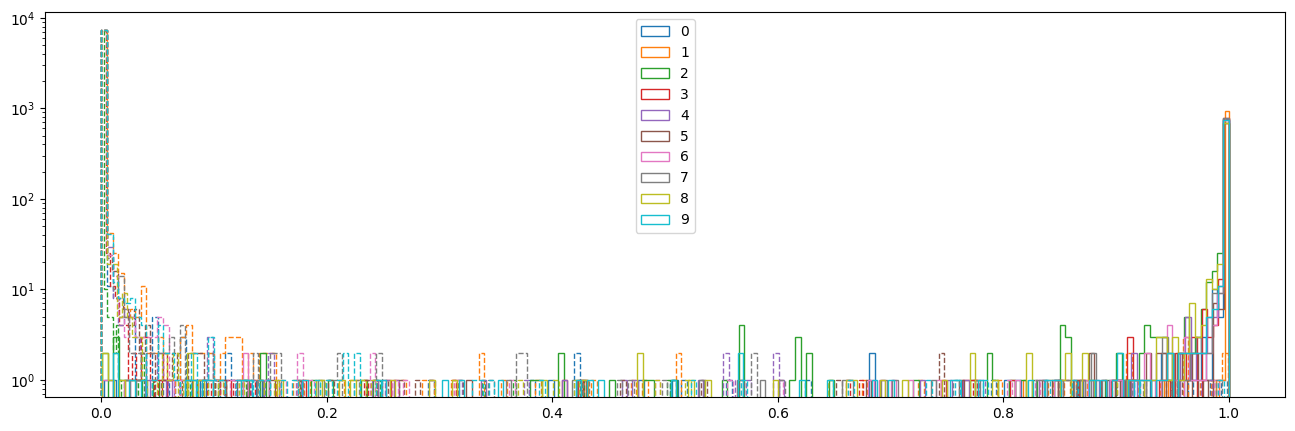

In [18]:
# Plot probability distributions
colors = sns.color_palette()
fig, ax = plt.subplots(figsize=(16, 5))

for cat in range(10):
    true_mask = test_batch["label"] == cat
    ax.hist(probs[cat][true_mask], 200, label=f"{cat}", color=colors[cat], histtype='step')
    ax.hist(probs[cat][~true_mask], 200, color=colors[cat], histtype='step', ls="--")
ax.set_yscale("log")
ax.legend()

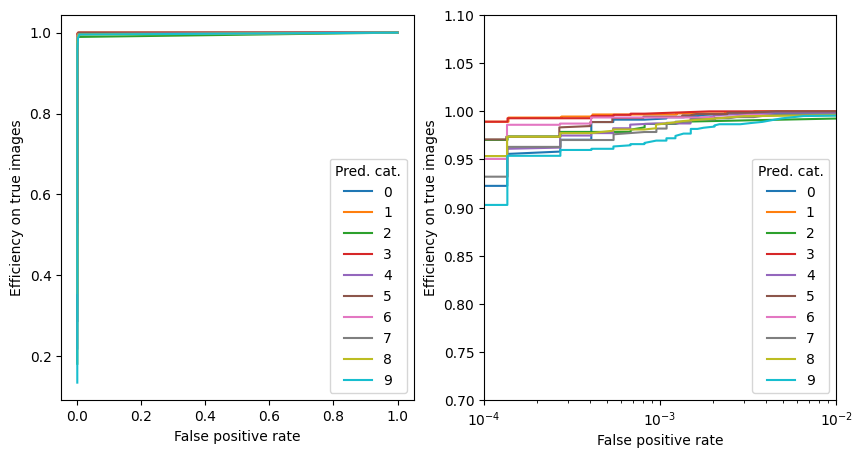

In [19]:
# Plot one-vs-all ROC curves
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
true_effs = {}
false_effs = {}
for pred_cat in range(10):
    #binary_results[cat]: (thresh, batch)
    true_mask = test_batch["label"] == pred_cat
    true_effs[pred_cat] = np.sum(binary_results[pred_cat][:, true_mask], axis=1) / np.sum(true_mask)
    false_effs[pred_cat] = np.sum(binary_results[pred_cat][:, ~true_mask], axis=1) / np.sum(~true_mask)
    axs.ravel()[0].plot(false_effs[pred_cat], true_effs[pred_cat], color=colors[pred_cat], label=f"{pred_cat}")
    axs.ravel()[1].plot(false_effs[pred_cat], true_effs[pred_cat], color=colors[pred_cat], label=f"{pred_cat}")
# Left plot: full ROC curve, linear axes
axs[0].set_xlabel("False positive rate")
axs[0].set_ylabel("Efficiency on true images")
axs[0].legend(title="Pred. cat.")

# Right plot: zoom interesting area, log x-axis
axs[1].set_xscale("log")
axs[1].set_xlim(1.e-4, 1.e-2)
axs[1].set_ylim(0.7, 1.1)
axs[1].set_xlabel("False positive rate")
axs[1].set_ylabel("Efficiency on true images")
axs[1].legend(title="Pred. cat.")

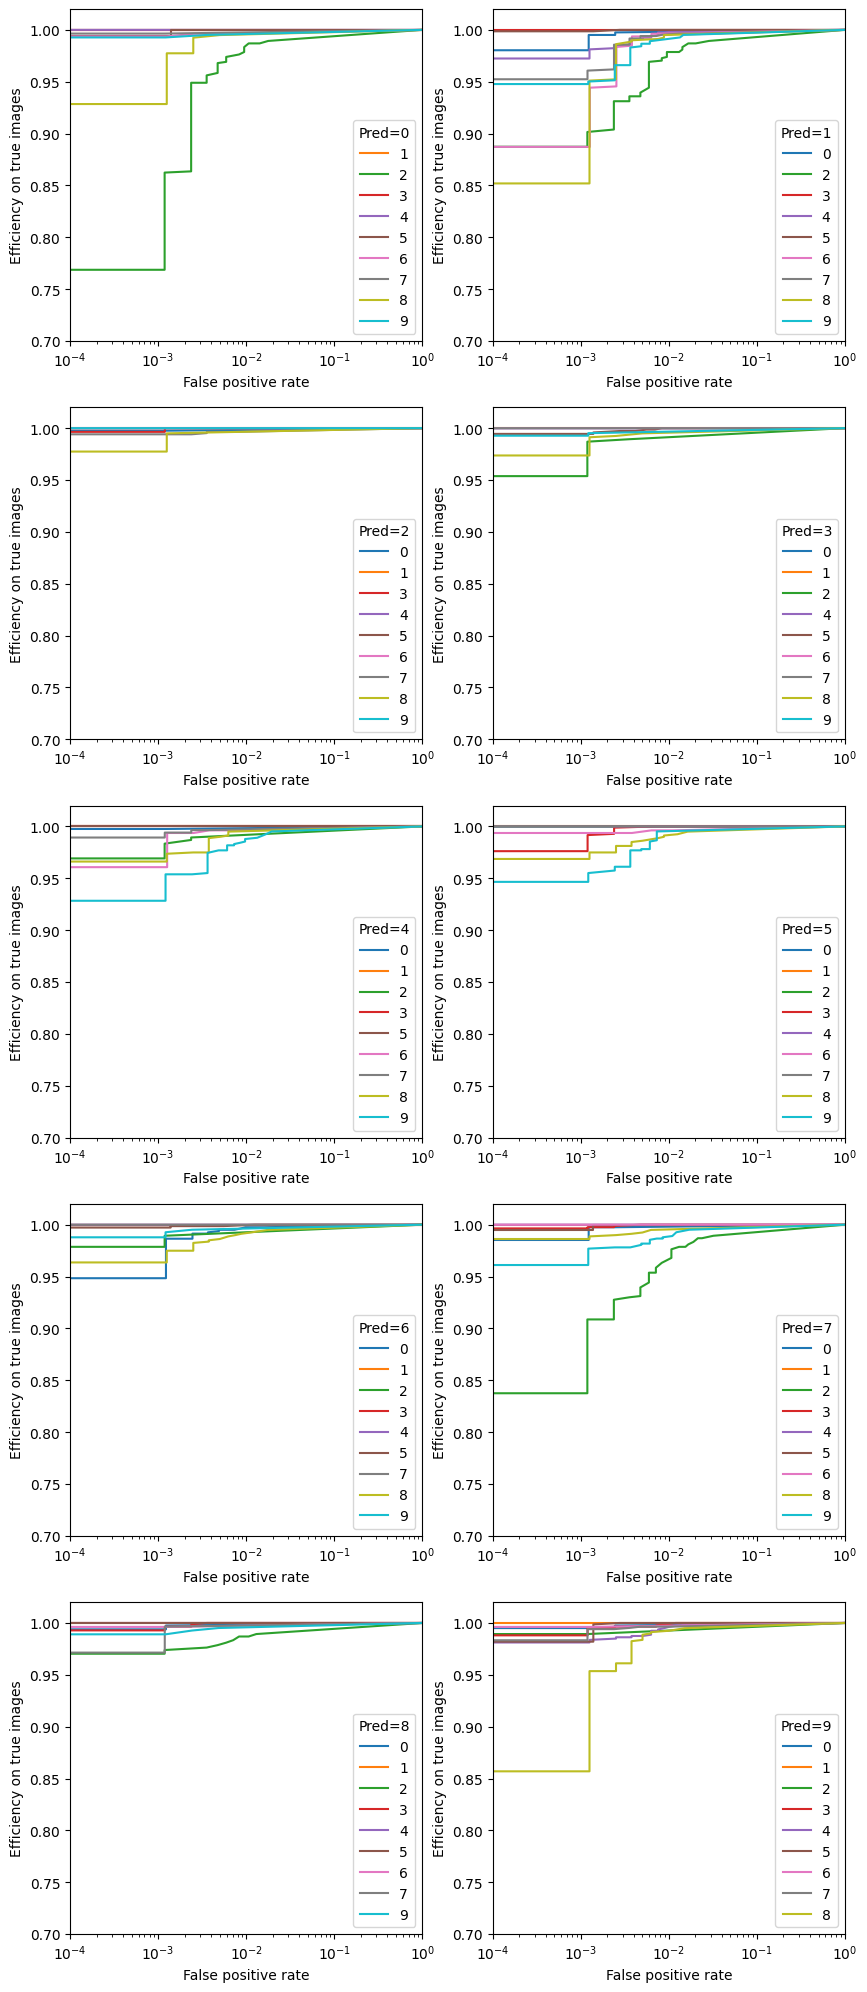

In [20]:
# Plot one-vs-one ROC curves
# Plot one-vs-all ROC curves
fig, axs = plt.subplots(5, 2, figsize=(10, 25))
true_effs = {}
false_effs = {}

# Truth classifications
true_masks = {}
for true_cat in range(10):
    true_masks[true_cat] = test_batch["label"] == cat

# Make ROC curves for each
eff_matrices = {} # key = (true_cat, pred_cat)
for pred_cat in range(10):
    for true_cat in range(10):
        true_mask = test_batch["label"] == true_cat
        eff_matrices[(true_cat, pred_cat)] = np.sum(binary_results[pred_cat][:, true_mask], axis=1) / np.sum(true_mask)

for pred_cat in range(10):    
    for true_cat in range(10):
        if pred_cat == true_cat: 
            continue
        axs.ravel()[pred_cat].plot(
            eff_matrices[(true_cat, pred_cat)], 
            eff_matrices[(true_cat, true_cat)], 
            color=colors[true_cat], label=f"{true_cat}")
    # Left plot: full ROC curve, linear axes
    axs.ravel()[pred_cat].set_xscale("log")
    axs.ravel()[pred_cat].set_xlim(1.e-4, 1.)
    axs.ravel()[pred_cat].set_ylim(0.7, 1.02)
    axs.ravel()[pred_cat].set_xlabel("False positive rate")
    axs.ravel()[pred_cat].set_ylabel("Efficiency on true images")
    axs.ravel()[pred_cat].legend(title=f"Pred={pred_cat}", loc="lower right")




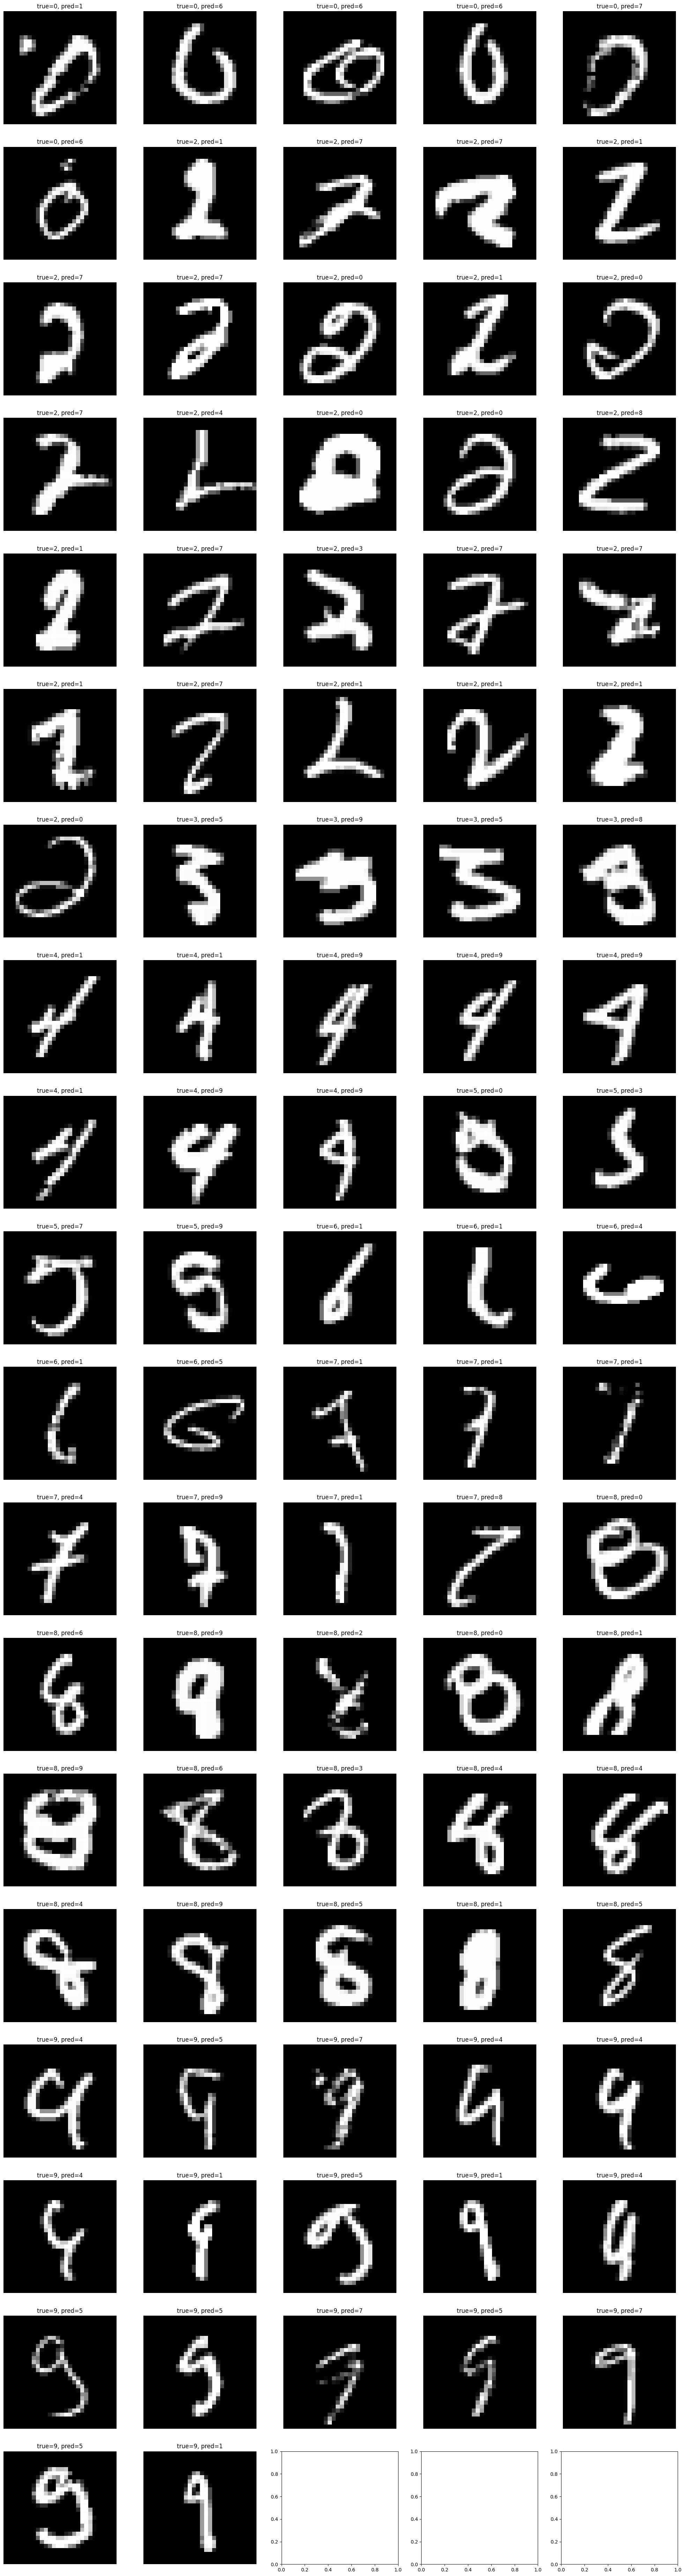

In [21]:
# Plot all mistakes
import math
bad_images = test_batch["image"][pred != test_batch["label"]]
bad_labels = test_batch["label"][pred != test_batch["label"]]
bad_preds = pred[pred != test_batch["label"]]
#print(bad_labels)

# Sort
sort_idx = np.argsort(bad_labels)
bad_images = bad_images[sort_idx]
bad_labels = bad_labels[sort_idx]
bad_preds = bad_preds[sort_idx]

confusion_matrix = hist.Hist(
    hist.axis.IntCategory(range(10), name="True"),
    hist.axis.IntCategory(range(10), name="Pred.")
)
confusion_matrix.fill(test_batch["label"], pred)


n = bad_labels.size
nrows = math.floor(n / 5.)+1
fig, axs = plt.subplots(nrows, 5, figsize=(25, 5*nrows))
if n == 0:
    print("No bad predictions")
elif n == 1:
    #print(bad_images)
    axs.imshow(bad_images[0], cmap="gray")
    axs.set_title(f"true={bad_labels[0]}, pred={bad_preds[0]}")
    axs.axis("off")
else:    
    for i in range(len(bad_images)):
        ax = axs.ravel()[i]
        ax.imshow(bad_images[i], cmap="gray")
        ax.set_title(f"true={bad_labels[i]}, pred={bad_preds[i]}")
        ax.axis("off")
    #for i, ax in enumerate(axs.ravel()):
    #    if i >= len(bad_images):
    #        continue

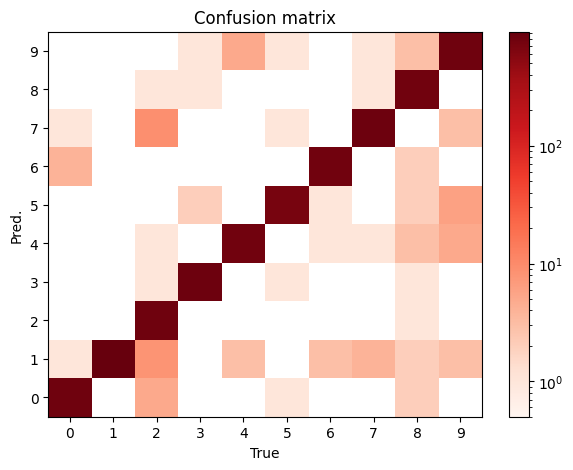

In [25]:
import matplotlib.ticker as plticker
from matplotlib.colors import LogNorm

loc = plticker.MultipleLocator(base=1.0) # this locator puts ticks at regular intervals

fig2, ax2 = plt.subplots(figsize=(7, 5))
w, x, y = confusion_matrix.to_numpy()
mesh = ax2.pcolormesh(x-0.5, y-0.5, w.T, cmap="Reds", norm=LogNorm(vmin=0.5, vmax=w.max()),)
ax2.set_xlabel("True")
ax2.set_ylabel("Pred.")
ax2.xaxis.set_major_locator(loc)
ax2.yaxis.set_major_locator(loc)
fig2.colorbar(mesh)
ax2.set_title("Confusion matrix")
plt.show()

# 8. Export the model

Flax models are great for research, but aren't meant to be deployed directly. Instead, high performance inference runtimes like LiteRT or TensorFlow Serving operate on a special [SavedModel](https://www.tensorflow.org/guide/saved_model) format. The [Orbax](https://orbax.readthedocs.io/en/latest/guides/export/orbax_export_101.html) library makes it easy to export Flax models to this format. First, we must create a `JaxModule` object wrapping a model and its prediction method.

In [26]:
from orbax.export import JaxModule, ExportManager, ServingConfig

In [27]:
def exported_predict(model, y):
    return model(y, None)

jax_module = JaxModule(eval_model, exported_predict)

We also need to tell Tensorflow Serving what input type `exported_predict` expects in its second argument. The export machinery expects type signature arguments to be PyTrees of `tf.TensorSpec`.

In [28]:
sig = [tf.TensorSpec(shape=(1, 28, 28, 1), dtype=tf.float32)]

Finally, we can bundle up the input signature and the `JaxModule` together using the `ExportManager` class.

In [29]:
export_mgr = ExportManager(jax_module, [
    ServingConfig('mnist_server', input_signature=sig)
])

output_dir='./mnist_export'
export_mgr.save(output_dir)

INFO:tensorflow:Assets written to: ./mnist_export/assets


INFO:tensorflow:Assets written to: ./mnist_export/assets


Congratulations! You have learned how to use Flax NNX to build and train a simple classification model end-to-end on the MNIST dataset.

Next, check out [Why Flax NNX?](https://flax.readthedocs.io/en/latest/why.html) and get started with a series of [Flax NNX Guides](https://flax.readthedocs.io/en/latest/guides/index.html).